|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>Understanding nn.Embedding and nn.Linear<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Create the two tensor objects

In [2]:
vocab_size = 5000
embed_dim = int(vocab_size**(1/2))
print(f'{vocab_size:,} tokens in the vocab, and {embed_dim} embedding dimensions.')

5,000 tokens in the vocab, and 70 embedding dimensions.


In [3]:
E = nn.Embedding(vocab_size,embed_dim ) # input [in  X out]
L = nn.Linear(    embed_dim,vocab_size) # input [out X in]

print(E)
print(L)
print(f'\nEmbedding matrix size: {E.weight.shape}')
print(f'Linear matrix size:    {L.weight.shape}')

Embedding(5000, 70)
Linear(in_features=70, out_features=5000, bias=True)

Embedding matrix size: torch.Size([5000, 70])
Linear matrix size:    torch.Size([5000, 70])


# Explore their attributes

In [4]:
len(dir(E)), len(dir(L))

(129, 123)

In [5]:
dir(E)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_fill_padding_idx_with_zero',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules

In [6]:
# unique attributes of each type
attrE = dir(E)
attrL = dir(L)

print('Attributes in Embedding that are not in Linear:')
for e in attrE:
  if e not in attrL:
    print('  ' + e)


print('\n\nAttributes in Linear that are not in Embedding:')
for l in attrL:
  if l not in attrE:
    print('  ' + l)

Attributes in Embedding that are not in Linear:
  _fill_padding_idx_with_zero
  embedding_dim
  from_pretrained
  max_norm
  norm_type
  num_embeddings
  padding_idx
  scale_grad_by_freq
  sparse


Attributes in Linear that are not in Embedding:
  bias
  in_features
  out_features


# Indexing their vectors

In [7]:
print(E.weight)
print('')
print(L.weight)

Parameter containing:
tensor([[ 0.4736,  1.4675, -1.3010,  ...,  0.9615, -1.1394,  0.8512],
        [-0.1979,  1.0528,  0.9520,  ..., -0.9605,  0.4861, -0.9466],
        [-1.1548, -0.0541, -0.0343,  ...,  0.1605, -0.3604,  0.0570],
        ...,
        [-0.8233,  1.1572, -1.5031,  ..., -0.0141,  1.6217, -0.3957],
        [ 0.7741,  0.1244,  0.4502,  ..., -0.2229,  0.0653, -1.1294],
        [-0.1572, -0.7132,  0.1979,  ...,  0.2852,  0.6580, -0.7686]],
       requires_grad=True)

Parameter containing:
tensor([[ 0.1142,  0.0672,  0.0527,  ..., -0.0216, -0.0269, -0.0321],
        [ 0.0253,  0.0020,  0.0063,  ...,  0.0910,  0.1105, -0.0824],
        [ 0.0670, -0.0793,  0.0742,  ..., -0.0775,  0.0610,  0.0332],
        ...,
        [-0.1023, -0.0516,  0.0713,  ...,  0.1003,  0.0129,  0.0504],
        [ 0.1138,  0.0003,  0.0049,  ...,  0.1035,  0.0468,  0.1004],
        [-0.1077, -0.1136,  0.0720,  ...,  0.0535,  0.0568, -0.0533]],
       requires_grad=True)


In [8]:
tokenidx = torch.tensor([14])
E(tokenidx) # emulates one-hot encoding

tensor([[-1.8072, -2.1843, -0.8714,  0.5592,  1.4895, -0.4180, -0.8258, -0.8882,
          1.1341,  0.2938,  1.1218,  0.6998,  0.2678,  2.2135,  1.1273,  1.0024,
         -1.2070, -0.5580,  0.7610,  0.5875,  0.7685,  0.6091, -0.1791,  1.9676,
         -0.7494, -0.7212,  0.0092, -1.1346,  2.0924,  0.2827, -0.2302,  1.1943,
          1.3882, -0.5111, -1.4931,  0.0034,  0.6410, -0.7805,  0.5802, -0.3121,
         -0.7009, -0.3416,  0.6914,  0.0997, -0.0934,  1.4721,  0.1461, -0.9645,
         -3.2860, -0.9884,  0.8619,  1.0171,  0.2257, -0.5454, -0.1779, -0.0351,
          1.1122, -0.1439,  0.9128,  0.5539,  1.1931, -1.1001,  0.5747,  0.9731,
         -1.3859,  0.9622, -0.9750,  0.5449,  1.3716,  1.3874]],
       grad_fn=<EmbeddingBackward0>)

In [9]:
# L(tokenidx)
L.weight[tokenidx,:]

tensor([[ 0.0604,  0.0278, -0.0030, -0.1038, -0.0159, -0.0499, -0.0870,  0.0916,
         -0.0363, -0.0241, -0.1162, -0.1137, -0.1154,  0.0130, -0.0173, -0.0885,
         -0.0705, -0.0220, -0.0746,  0.0474, -0.0055, -0.0358, -0.0635, -0.1067,
         -0.0907,  0.0285,  0.0804,  0.1100, -0.0382, -0.0701, -0.0144, -0.0360,
          0.0056,  0.0063, -0.0877,  0.0931,  0.0331, -0.0983,  0.0323,  0.0971,
          0.0637,  0.0576, -0.0383, -0.0811,  0.0507,  0.0804, -0.0716, -0.1053,
          0.0645,  0.0166,  0.0185,  0.0941,  0.0834,  0.0416,  0.0852,  0.0691,
          0.0923, -0.0294,  0.0977, -0.1007, -0.0182,  0.0894, -0.0645, -0.0532,
          0.0070,  0.0897,  0.1193,  0.0320, -0.0296, -0.1009]],
       grad_fn=<IndexBackward0>)

In [10]:
# explicit one-hot encoding with vector-matrix multiplication
oneHotVect = torch.zeros(vocab_size,1)
oneHotVect[tokenidx] = 1

# as vector-matrix multiplication
oneHotVect.t() @ L.weight

tensor([[ 0.0604,  0.0278, -0.0030, -0.1038, -0.0159, -0.0499, -0.0870,  0.0916,
         -0.0363, -0.0241, -0.1162, -0.1137, -0.1154,  0.0130, -0.0173, -0.0885,
         -0.0705, -0.0220, -0.0746,  0.0474, -0.0055, -0.0358, -0.0635, -0.1067,
         -0.0907,  0.0285,  0.0804,  0.1100, -0.0382, -0.0701, -0.0144, -0.0360,
          0.0056,  0.0063, -0.0877,  0.0931,  0.0331, -0.0983,  0.0323,  0.0971,
          0.0637,  0.0576, -0.0383, -0.0811,  0.0507,  0.0804, -0.0716, -0.1053,
          0.0645,  0.0166,  0.0185,  0.0941,  0.0834,  0.0416,  0.0852,  0.0691,
          0.0923, -0.0294,  0.0977, -0.1007, -0.0182,  0.0894, -0.0645, -0.0532,
          0.0070,  0.0897,  0.1193,  0.0320, -0.0296, -0.1009]],
       grad_fn=<MmBackward0>)

# Distributions of weights at initialization

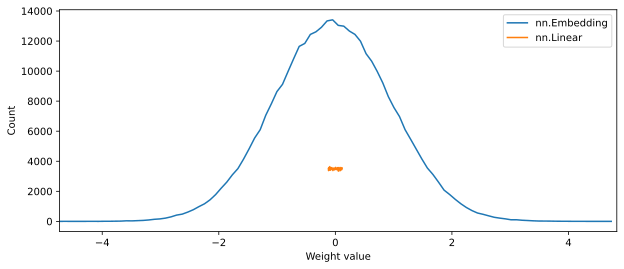

In [11]:
# extract histograms to get empirical distributions
Ey,Ex = np.histogram(E.weight.flatten().detach(),100)
Ly,Lx = np.histogram(L.weight.flatten().detach(),100)

plt.figure(figsize=(10,4))
plt.plot(Ex[:-1],Ey,label='nn.Embedding')
plt.plot(Lx[:-1],Ly,label='nn.Linear')

plt.gca().set(xlim=[np.min(Ex),np.max(Ex)],xlabel='Weight value',ylabel='Count')
plt.legend()
plt.show()

In [12]:
# Note: More on weights initialization in video
# "Weight initializations" in section "Pretrain LLMs"

print('*** Statistics of nn.Linear weights ***\n')
print(f'Kaiming expected std: { np.sqrt(1/embed_dim)/np.sqrt(3) :.4f}')
print(f'Observed std of L: {torch.std(L.weight.detach()) :.4f}')

print(f'\nKaiming expected bounds: {np.sqrt(1/embed_dim):.4f}')
print(f'Observed min/max vals: [{torch.min(L.weight):.4f},{torch.max(L.weight):.4f}]')

*** Statistics of nn.Linear weights ***

Kaiming expected std: 0.0690
Observed std of L: 0.0690

Kaiming expected bounds: 0.1195
Observed min/max vals: [-0.1195,0.1195]


In [13]:
# repeat the above for Xavier
print('*** Statistics of nn.Embeddings weights ***\n')
print(f'Xavier expected std: { np.sqrt(2/(vocab_size+embed_dim)) :.4f}')
print(f'Observed std of E: {torch.std(E.weight.detach()) :.4f}') # it's normal, not Xavier

*** Statistics of nn.Embeddings weights ***

Xavier expected std: 0.0199
Observed std of E: 1.0014


In [14]:
# initialize L to match properties of E
Ln = nn.Linear(embed_dim,vocab_size) # new matrix to avoid overwriting
torch.nn.init.normal_(Ln.weight)

Parameter containing:
tensor([[-1.7469,  1.0493,  0.1790,  ...,  0.6417, -0.3079,  2.1518],
        [ 0.3686, -0.5481,  1.0071,  ..., -1.4048,  0.3858,  0.5354],
        [-0.5501, -1.3884, -1.7293,  ..., -0.3119,  2.5748, -0.2520],
        ...,
        [-1.3267,  1.0465, -1.6435,  ..., -0.4668,  0.1815, -0.3323],
        [-0.5461,  0.6788,  0.0583,  ..., -0.7357, -1.8073,  0.8118],
        [-1.7293,  0.7011, -0.0176,  ...,  0.2317, -0.2870, -1.2909]],
       requires_grad=True)

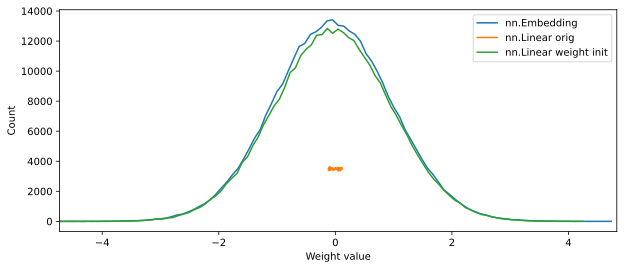

In [15]:
Lny,Lnx = np.histogram(Ln.weight.flatten().detach(),100)

plt.figure(figsize=(10,4))
plt.plot(Ex[:-1],Ey,label='nn.Embedding')
plt.plot(Lx[:-1],Ly,label='nn.Linear orig')
plt.plot(Lnx[:-1],Lny,label='nn.Linear weight init')

plt.gca().set(xlim=[np.min(Ex),np.max(Ex)],xlabel='Weight value',ylabel='Count')
plt.legend()
plt.show()

In [16]:
# both created via nn.Parameter
??nn.Embedding
??nn.Linear

Init signature:
nn.Linear(
    in_features: int,
    out_features: int,
    bias: bool = True,
    device=None,
    dtype=None,
) -> None
Source:        
class Linear(Module):
    r"""Applies an affine linear transformation to the incoming data: :math:`y = xA^T + b`.

    This module supports :ref:`TensorFloat32<tf32_on_ampere>`.

    On certain ROCm devices, when using float16 inputs this module will use :ref:`different precision<fp16_on_mi200>` for backward.

    Args:
        in_features: size of each input sample
        out_features: size of each output sample
        bias: If set to ``False``, the layer will not learn an additive bias.
            Default: ``True``

    Shape:
        - Input: :math:`(*, H_\text{in})` where :math:`*` means any number of
          dimensions including none and :math:`H_\text{in} = \text{in\_features}`.
        - Output: :math:`(*, H_\text{out})` where all but the last dimension
          are the same shape as the input and :math:`H_\text{out} = \t

In [17]:
# Conclusions:
#   1) Embeddings weights are initialized as standard normal, not Xavier normal.
#   2) they are "different" for practical reasons but reflect the same thing (trainable random weights)